# Power Simulation with PyBaMM

This notebook demonstrates how to perform constant power discharge simulation using PyBaMM with BYD Blade Prismatic 135Ah cell parameters.

## Overview
- **Cell**: BYD Blade Prismatic 135Ah LFP
- **Chemistry**: LFP (Lithium Iron Phosphate)
- **Form Factor**: Prismatic
- **Nominal Voltage**: 3.3V
- **Capacity**: 135Ah
- **Simulations**: Constant power discharge at multiple power levels

In [6]:
# Import required libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_spmet

## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [7]:
# Load cell manifest
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
material_path = Path("../materials")
# manifest_path = Path("../cells/BYD_Blade_Prismatic_135Ah_manifest.json")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
    # Load material data for separator and electrolyte
    for component in ["separator", "electrolyte"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["material"]["type"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

    # Load material data for electrodes
    for component in ["negative_electrode", "positive_electrode"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["coating"]["formulation"]["primary_active_material"]["name"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

nominal_capacity = cell_design_manifest['kpis']['nominal_capacity']['value']
nominal_energy = cell_design_manifest["kpis"]["nominal_energy"]["value"] 
cell_design = cell_design_manifest["cell_design"]
upper_voltage_cutoff = cell_design["upper_voltage_cutoff"][
    "value"
]
lower_voltage_cutoff = cell_design_manifest["cell_design"]["lower_voltage_cutoff"][
    "value"
]
cell_design["nominal_capacity"] = {"value": nominal_capacity, "unit": "Ah"}
cell_design["nominal_energy"] = {"value": nominal_energy, "unit": "Wh"}

cell_design["cell_volume"] = {
    "value": cell_design_manifest['kpis']['cell_volume']['value'],
    "unit": "cm3"
}


Loading material data for separator
Loading material data for electrolyte
Loading material data for negative_electrode
Loading material data for positive_electrode


## 2. Run Power Simulation

Run the SPMeT model with power experiment configuration at multiple power levels.

In [8]:

# ============================================================================
# POWER TEST CONFIGURATION
# ============================================================================
power_levels_W = [10, 50,100, 500, 1000]

# Build experiment strings for each power level
experiments = []
labels = []
for power_W in power_levels_W:
    max_time_s = int(nominal_energy / power_W * 3600 * 1.2)  # 20% margin
    experiments.append(f"Discharge at {power_W}W for {max_time_s} seconds or until {lower_voltage_cutoff} V")
    labels.append(f"{power_W}W")

# Power test configuration dictionary
power_config = {
    "ambient_temperature": 298.15,  # 25°C
    "initial_temperature": 298.15,  # 25°C
    "initial_soc": 0.5,  # 50% SOC
    "c_rate": 1.0,  # 1C discharge
    "direction": "discharge",
    "duration_s": 30,
    "upper_voltage_cutoff": upper_voltage_cutoff,
    "lower_voltage_cutoff": lower_voltage_cutoff,
    "contact_resistance": 0.0001,
    "total_heat_transfer_coefficient": 10,
    "cooling_surface_area": 0.001,
    "experiments": experiments,
    "experiment_labels": labels,
}
results = run_spmet(cell_design=cell_design, simulation_config=power_config)


Building model parameters from manifest...

CAPACITY CALIBRATION
Target capacity: 161.10 Ah
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  60.04 Ah, Error = 62.732%
Iteration  2: Capacity = 163.33 Ah, Error =  1.387%
Iteration  3: Capacity = 161.08 Ah, Error =  0.012%
Iteration  4: Capacity = 161.11 Ah, Error =  0.007%
--------------------------------------------------------------------------------
Converged after 4 iterations!

RUNNING EXPERIMENTS

Running: 10W
  Experiment: Discharge at 10W for 222702 seconds or until 2.5 V
  Completed: 57 data points

Running: 50W
  Experiment: Discharge at 50W for 44540 seconds or until 2.5 V
  Completed: 63 data points

Running: 100W
  Experiment: Discharge at 100W for 22270 seconds or until 2.5 V
  Completed: 73 data points

Running: 500W
  Experiment: Discharge at 500W for 4454 seconds or until 2.5 V
  Completed: 76 data points

Running: 1000W
  Experiment

## 3. Post-Processing: Calculate Power Metrics

Extract energy, duration, and other metrics from the raw time series data.

In [9]:
# Post-processing: Calculate power metrics from time series
successful_results = [r for r in results if r['success']]

power_metrics = []
for r in successful_results:
    time_s = r['time_s']
    voltage_V = r['voltage_V']
    energy_Wh = r['energy_Wh']
    temperature_K = r['temperature_K']
    
    # Calculate metrics
    discharge_energy_Wh = float(energy_Wh[-1] - energy_Wh[0])
    discharge_time_s = float(time_s[-1] - time_s[0])
    discharge_time_min = discharge_time_s / 60
    max_temperature_C = float(temperature_K.max() - 273.15)
    
    # Extract power from label
    power_W = int(r['experiment_label'].replace('W', ''))
    
    power_metrics.append({
        'power_W': power_W,
        'discharge_energy_Wh': discharge_energy_Wh,
        'discharge_time_min': discharge_time_min,
        'max_temperature_C': max_temperature_C,
        'time_s': time_s,
        'voltage_V': voltage_V,
        'temperature_K': temperature_K,
    })

# Display summary
if power_metrics:
    summary_data = [{
        'Power [W]': m['power_W'],
        'Energy [Wh]': f"{m['discharge_energy_Wh']:.2f}",
        'Duration [min]': f"{m['discharge_time_min']:.1f}",
        'Max Temp [C]': f"{m['max_temperature_C']:.1f}",
    } for m in power_metrics]
    
    summary_df = pd.DataFrame(summary_data)
    print("\nPower Simulation Results:")
    print(summary_df.to_string(index=False))


Power Simulation Results:
 Power [W] Energy [Wh] Duration [min] Max Temp [C]
        10      258.91         1553.4         34.0
        50      252.33          302.8         35.3
       100      245.28          147.2         35.8
       500      209.48           25.1         38.5
      1000      182.68           11.0         41.2


## 4. Visualize Results

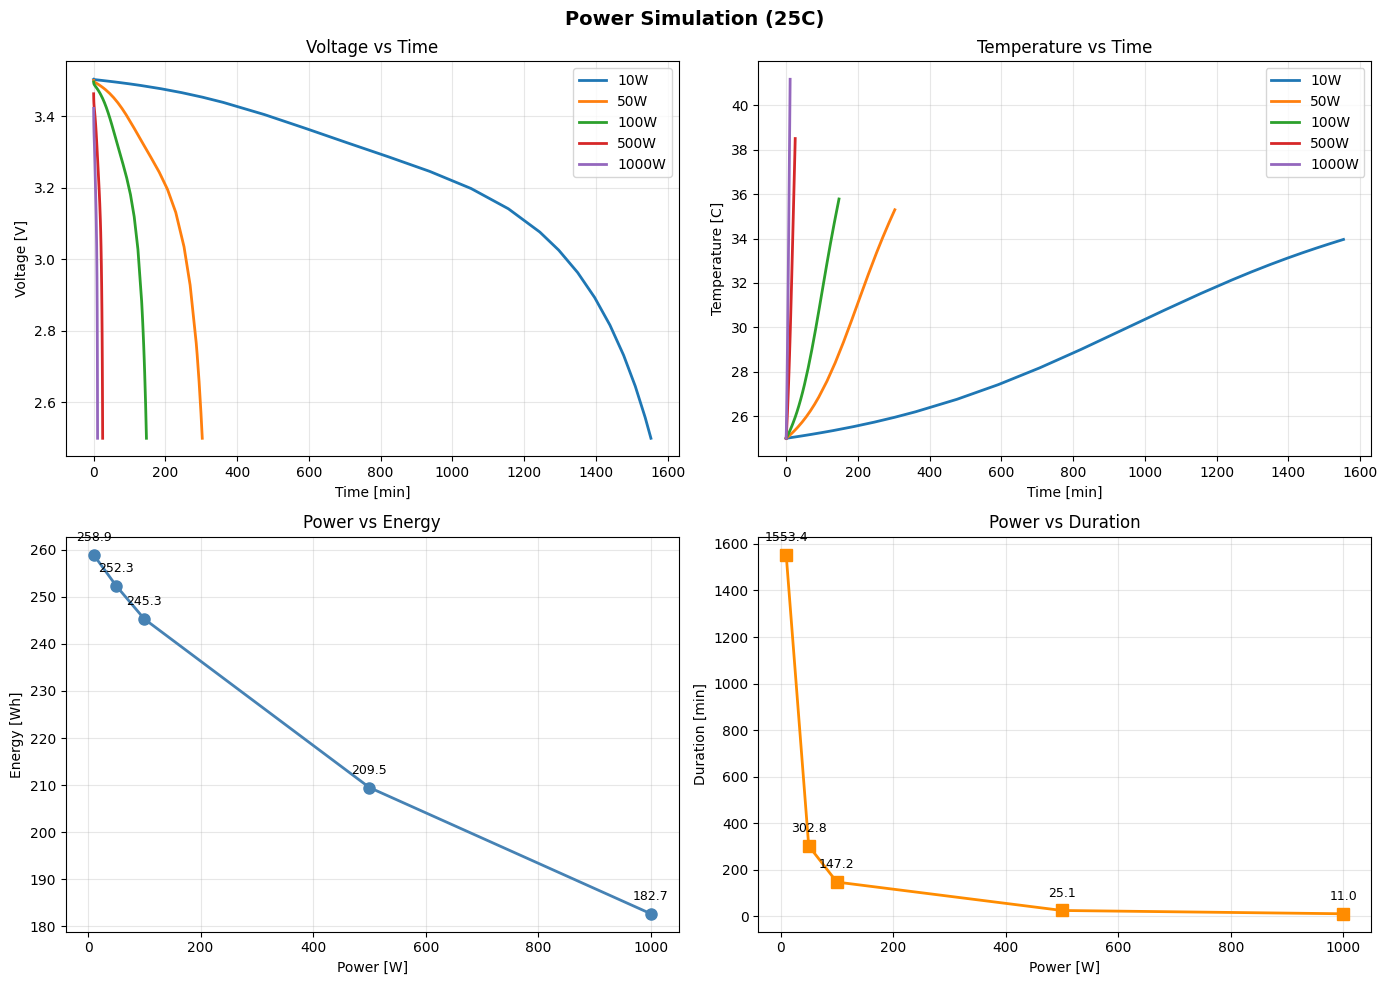

In [10]:
if len(power_metrics) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Voltage vs Time for all power levels
    ax1 = axes[0, 0]
    for m in power_metrics:
        time_min = (m['time_s'] - m['time_s'][0]) / 60
        ax1.plot(time_min, m['voltage_V'], linewidth=2, label=f"{m['power_W']}W")
    ax1.set_xlabel('Time [min]')
    ax1.set_ylabel('Voltage [V]')
    ax1.set_title('Voltage vs Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Temperature vs Time for all power levels
    ax2 = axes[0, 1]
    for m in power_metrics:
        time_min = (m['time_s'] - m['time_s'][0]) / 60
        temp_C = m['temperature_K'] - 273.15
        ax2.plot(time_min, temp_C, linewidth=2, label=f"{m['power_W']}W")
    ax2.set_xlabel('Time [min]')
    ax2.set_ylabel('Temperature [C]')
    ax2.set_title('Temperature vs Time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Power vs Energy
    ax3 = axes[1, 0]
    power_levels_plot = [m['power_W'] for m in power_metrics]
    energies = [m['discharge_energy_Wh'] for m in power_metrics]
    ax3.plot(power_levels_plot, energies, 'o-', linewidth=2, markersize=8, color='steelblue')
    ax3.set_xlabel('Power [W]')
    ax3.set_ylabel('Energy [Wh]')
    ax3.set_title('Power vs Energy')
    ax3.grid(True, alpha=0.3)
    for p, e in zip(power_levels_plot, energies):
        ax3.annotate(f'{e:.1f}', (p, e), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

    # Plot 4: Power vs Duration
    ax4 = axes[1, 1]
    durations = [m['discharge_time_min'] for m in power_metrics]
    ax4.plot(power_levels_plot, durations, 's-', linewidth=2, markersize=8, color='darkorange')
    ax4.set_xlabel('Power [W]')
    ax4.set_ylabel('Duration [min]')
    ax4.set_title('Power vs Duration')
    ax4.grid(True, alpha=0.3)
    for p, d in zip(power_levels_plot, durations):
        ax4.annotate(f'{d:.1f}', (p, d), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

    plt.suptitle(f'Power Simulation ({power_config["ambient_temperature"]-273.15:.0f}C)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No successful simulations to plot.")